# Week 2 Project — Member 3 — Random Forest Regressor + XGBoost Classifier
Two-stage pipeline (per spec):
- **Part A (Regression):** Predict `CCAvg` → create `Predicted_CCAvg`
- **Part B (Classification):** Predict `Personal_Loan` using `Predicted_CCAvg` **without using actual `CCAvg`**


In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix


## Load data

In [2]:
file_path = "Loan_Modelling.xlsx"
df = pd.read_excel(file_path)

# Standardize column names
df = df.rename(columns={"ZIP Code": "ZIPCode"})

print("Shape:", df.shape)
display(df.head())


Shape: (5000, 14)


,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


## Data cleaning

In [3]:
# Fix negative Experience (if any)
if "Experience" in df.columns:
    neg_exp = (df["Experience"] < 0).sum()
    if neg_exp > 0:
        median_exp = df.loc[df["Experience"] >= 0, "Experience"].median()
        df.loc[df["Experience"] < 0, "Experience"] = median_exp
        print(f"Fixed {neg_exp} negative Experience values using median={median_exp}.")
    else:
        print("No negative Experience values found.")

# Drop identifier
if "ID" in df.columns:
    df = df.drop(columns=["ID"])

# Drop ZIPCode to avoid treating it as numeric (unless you one-hot encode)
if "ZIPCode" in df.columns:
    df = df.drop(columns=["ZIPCode"])

# Handle missing values (simple median fill for numeric)
num_cols = df.select_dtypes(include=[np.number]).columns
for c in num_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].median())

print("Missing values total:", df.isna().sum().sum())
display(df.describe(include="all"))


Fixed 52 negative Experience values using median=20.0.
Missing values total: 0


,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,45.338400,20.327600,73.774200,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,11.463166,11.253035,46.033729,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,23.000000,0.000000,8.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,35.000000,11.000000,39.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,45.000000,20.000000,64.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,55.000000,30.000000,98.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,67.000000,43.000000,224.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


## Univariate + bivariate EDA

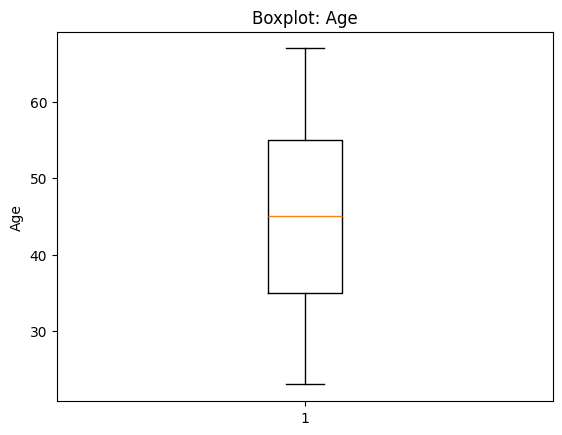

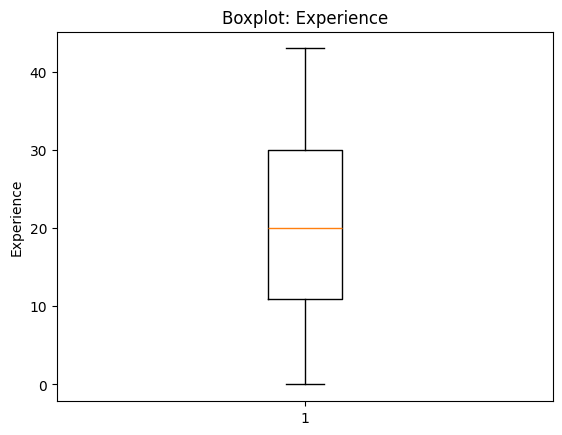

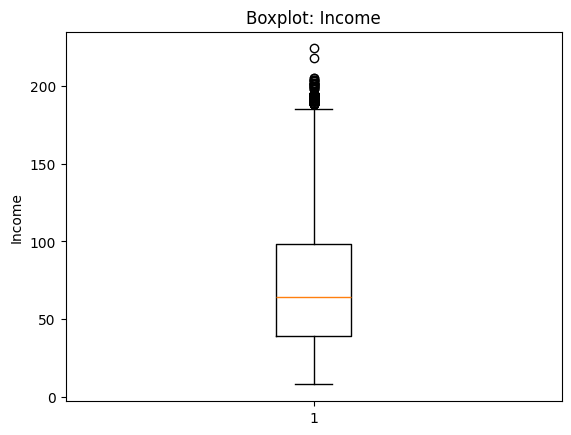

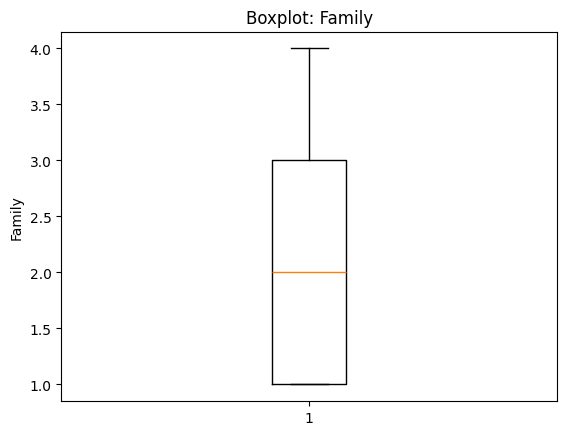

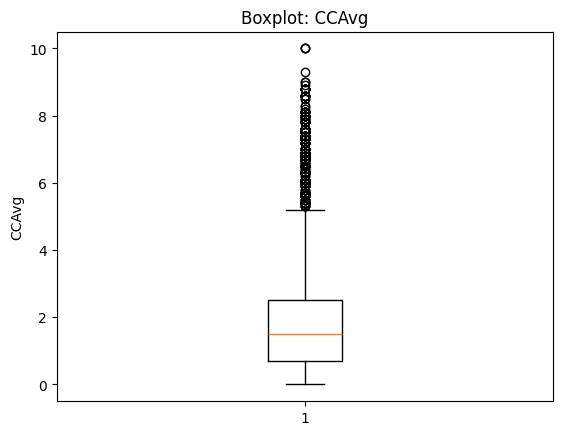

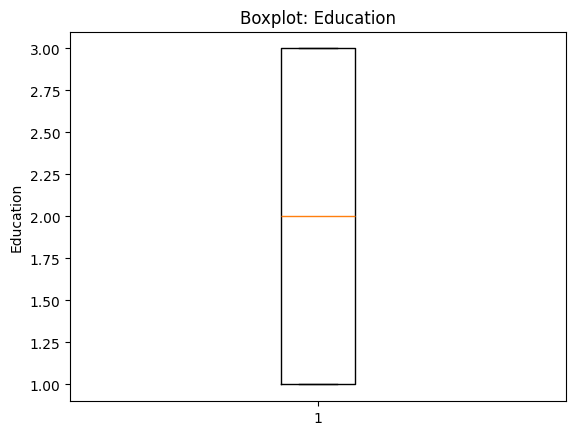

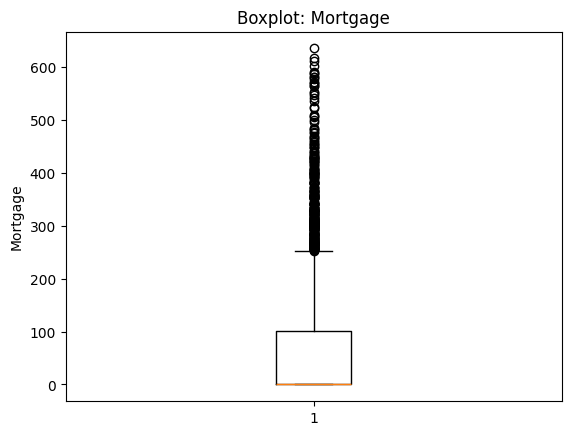

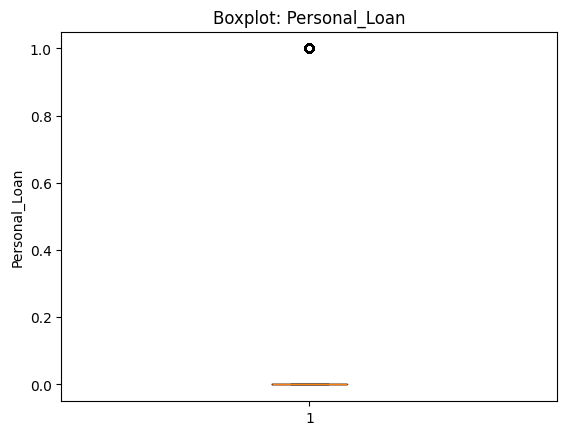

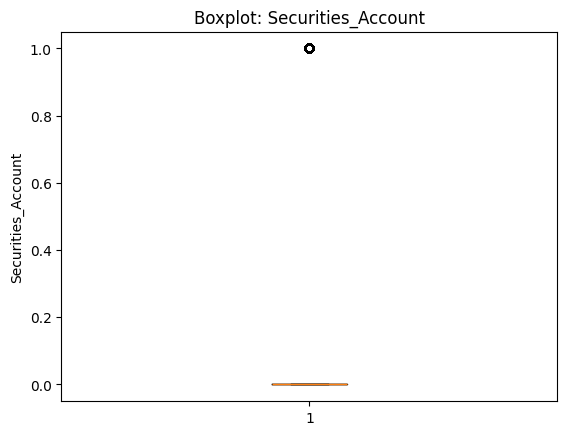

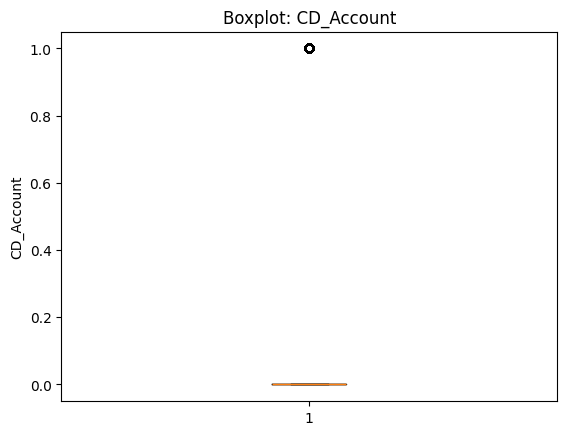

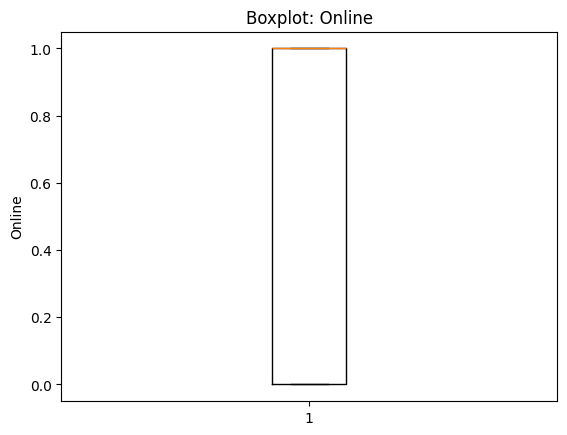

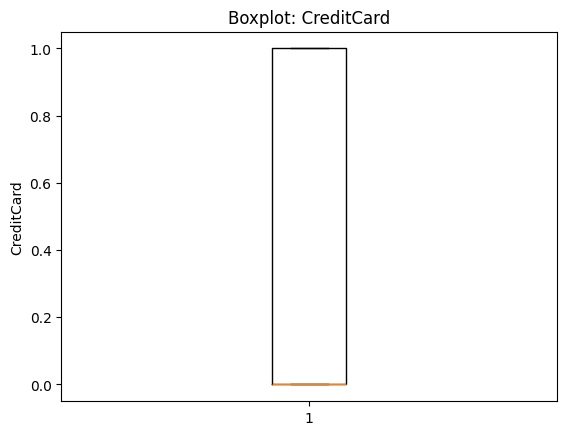

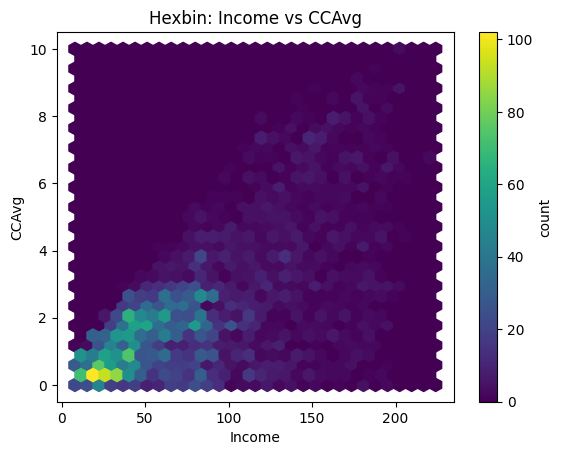

/tmp/ipython-input-2366952702.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby(bins)["CCAvg"].mean()


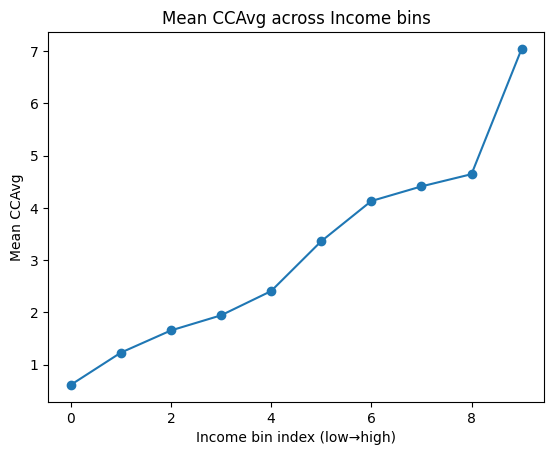

In [4]:

target_reg = "CCAvg"
target_clf = "Personal_Loan"

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Univariate: boxplots (different from hist/kde)
for col in num_cols:
    plt.figure()
    plt.boxplot(df[col].dropna(), vert=True)
    plt.title(f"Boxplot: {col}")
    plt.ylabel(col)
    plt.show()

# Bivariate: hexbin Income vs CCAvg (different graph)
if "Income" in df.columns and "CCAvg" in df.columns:
    plt.figure()
    plt.hexbin(df["Income"], df["CCAvg"], gridsize=30)
    plt.title("Hexbin: Income vs CCAvg")
    plt.xlabel("Income")
    plt.ylabel("CCAvg")
    plt.colorbar(label="count")
    plt.show()

# Bivariate: mean Predicted relationship proxy using group means (Income bins)
if "Income" in df.columns and "CCAvg" in df.columns:
    bins = pd.cut(df["Income"], bins=10)
    means = df.groupby(bins)["CCAvg"].mean()
    plt.figure()
    plt.plot(range(len(means)), means.values, marker="o")
    plt.title("Mean CCAvg across Income bins")
    plt.xlabel("Income bin index (low→high)")
    plt.ylabel("Mean CCAvg")
    plt.show()


## Correlation analysis

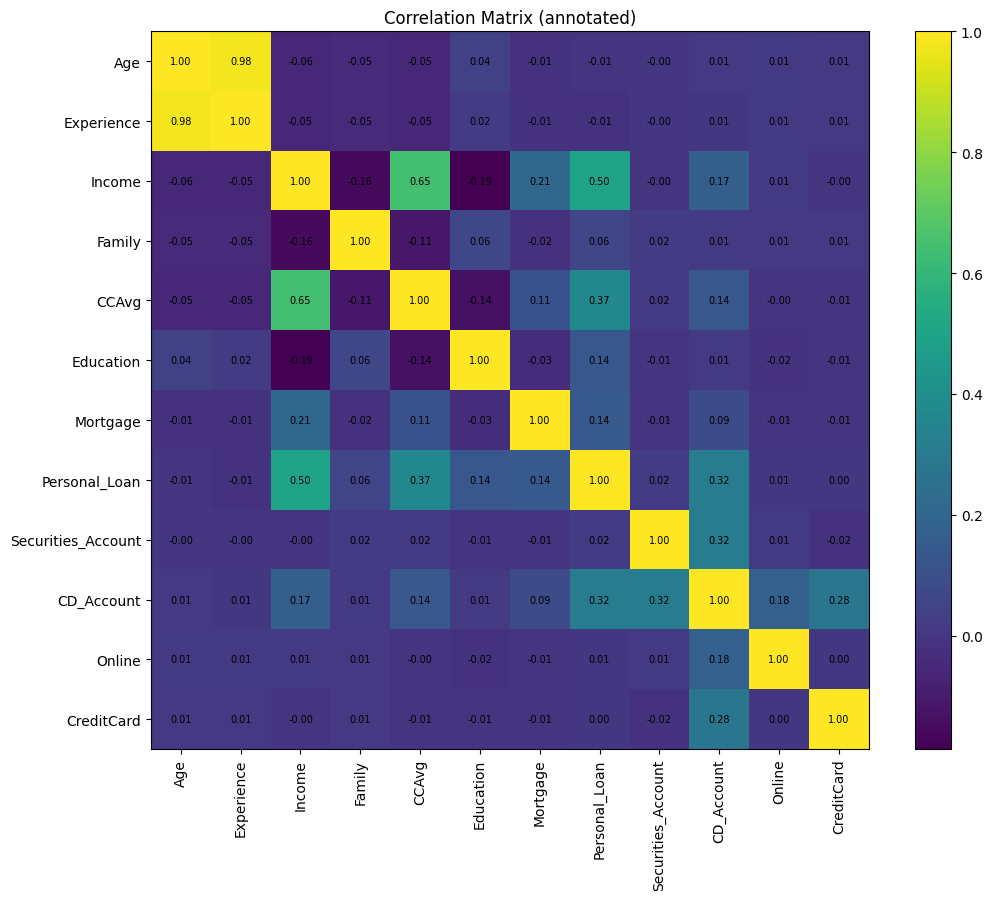

In [5]:

corr = df.select_dtypes(include=[np.number]).corr()

# Annotated correlation (numbers on plot) — visually different
cols = corr.columns.tolist()
plt.figure(figsize=(11, 9))
plt.imshow(corr)
plt.xticks(range(len(cols)), cols, rotation=90)
plt.yticks(range(len(cols)), cols)
plt.title("Correlation Matrix (annotated)")
plt.colorbar()
for i in range(len(cols)):
    for j in range(len(cols)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
plt.tight_layout()
plt.show()


# Part A — Regression (Target: CCAvg)

In [6]:

from sklearn.ensemble import RandomForestRegressor

target_reg = "CCAvg"
target_clf = "Personal_Loan"

reg_features = [c for c in df.columns if c not in [target_reg, target_clf]]
X_reg = df[reg_features]
y_reg = df[target_reg]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.30, random_state=42
)

reg_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    min_samples_split=10
)
reg_model.fit(X_train_reg, y_train_reg)

y_train_pred = reg_model.predict(X_train_reg)
y_test_pred  = reg_model.predict(X_test_reg)

train_rmse = np.sqrt(mean_squared_error(y_train_reg, y_train_pred))
test_rmse  = np.sqrt(mean_squared_error(y_test_reg, y_test_pred))
train_r2   = r2_score(y_train_reg, y_train_pred)
test_r2    = r2_score(y_test_reg, y_test_pred)

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE : {test_rmse:.4f}")
print(f"Train R2  : {train_r2:.4f}")
print(f"Test R2   : {test_r2:.4f}")

# Create Predicted_CCAvg (fit on full data)
reg_model_full = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    min_samples_split=10
).fit(X_reg, y_reg)

df["Predicted_CCAvg"] = reg_model_full.predict(X_reg)

display(df[[target_reg, "Predicted_CCAvg"]].head())


Train RMSE: 0.8171
Test RMSE : 1.2693
Train R2  : 0.7818
Test R2   : 0.4699


,CCAvg,Predicted_CCAvg
0,1.6,1.367200
1,1.5,1.068126
2,1.0,0.647514
3,2.7,2.666526
4,1.0,0.957684


# Part B — Classification (Target: Personal_Loan)
**Leakage rule:** do not use actual `CCAvg` as an input feature. Use `Predicted_CCAvg`.

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1356
           1       0.85      0.93      0.89       144

    accuracy                           0.98      1500
   macro avg       0.92      0.96      0.94      1500
weighted avg       0.98      0.98      0.98      1500

Confusion Matrix [[TN, FP],[FN, TP]]:
[[1333   23]
 [  10  134]]


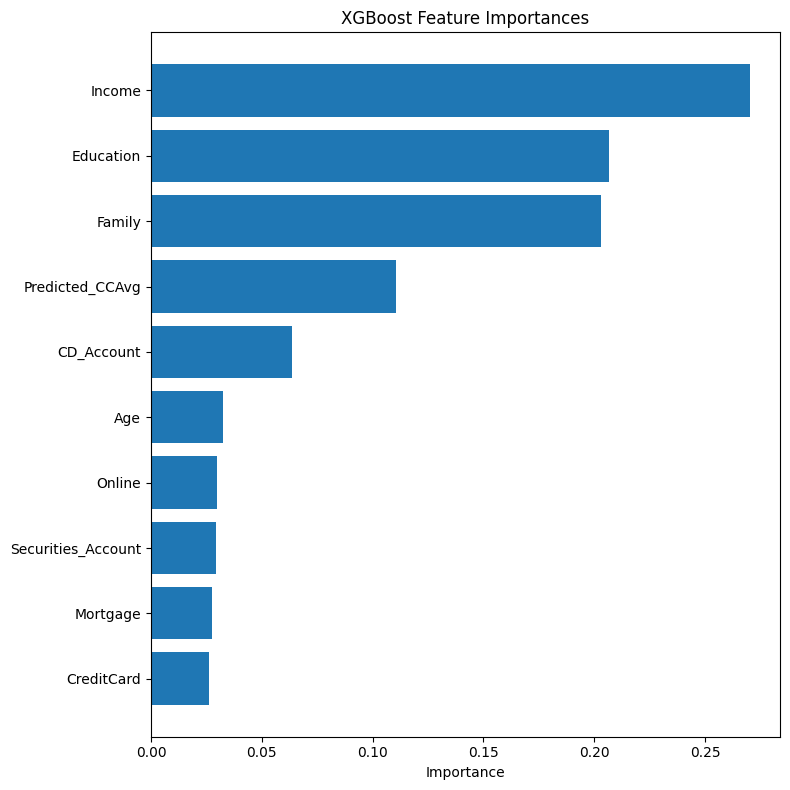

In [7]:

# xgboost

target_reg = "CCAvg"
target_clf = "Personal_Loan"

clf_features = [c for c in df.columns if c not in [target_clf, target_reg]]
if "Experience" in clf_features and "Age" in clf_features:
    clf_features.remove("Experience")

X = df[clf_features]
y = df[target_clf]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

try:
    from xgboost import XGBClassifier

    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = neg / max(pos, 1)

    xgb = XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight
    )

    xgb.fit(X_train, y_train)
    y_pred = xgb.predict(X_test)

    print(classification_report(y_test, y_pred, zero_division=0))
    print("Confusion Matrix [[TN, FP],[FN, TP]]:")
    print(confusion_matrix(y_test, y_pred))

    # Feature importances
    importances = xgb.feature_importances_
    idx = np.argsort(importances)
    plt.figure(figsize=(8, 8))
    plt.title("XGBoost Feature Importances")
    plt.barh(range(len(idx)), importances[idx])
    plt.yticks(range(len(idx)), [clf_features[i] for i in idx])
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("XGBoost not available in this environment:", e)


## Short business notes
- `Predicted_CCAvg` is an engineered behavioral feature.
- For imbalanced `Personal_Loan`, report class-1 precision/recall/F1 and confusion matrix.
- Marketing context: higher recall can be acceptable if outreach cost is low.

## Model Performance Summary Table
This table summarizes final model performance for clear comparison.


In [8]:
# Create summary table (Regression + Classification)
import pandas as pd

# Regression summary
reg_summary = pd.DataFrame({
    'Metric': ['Train RMSE','Test RMSE','Train R2','Test R2'],
    'Value': [train_rmse, test_rmse, train_r2, test_r2]
})

print('=== Regression Summary ===')
display(reg_summary)

# Classification summary (class 1 focus)
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
accuracy = accuracy_score(y_test, y_pred)

clf_summary = pd.DataFrame({
    'Metric': ['Accuracy','Precision (Loan=1)','Recall (Loan=1)','F1 Score (Loan=1)'],
    'Value': [accuracy, precision, recall, f1]
})

print('=== Classification Summary ===')
display(clf_summary)


=== Regression Summary ===


,Metric,Value
0,Train RMSE,0.817091
1,Test RMSE,1.269350
2,Train R2,0.781794
3,Test R2,0.469930


=== Classification Summary ===


,Metric,Value
0,Accuracy,0.978000
1,Precision (Loan=1),0.853503
2,Recall (Loan=1),0.930556
3,F1 Score (Loan=1),0.890365


## Key Business Insights
1. **Income is the strongest driver of credit card spending**, indicating higher-income customers are more financially active.
2. **Predicted_CCAvg improves loan targeting**, showing behavioral spending is linked to loan acceptance.
3. The dataset is imbalanced (~90% non-loan), so **recall for Loan=1 is critical** in marketing strategy.
4. Tree-based models capture non-linear relationships better, while linear models provide interpretability.
